In [3]:
from google.colab import files
import os

os.makedirs('/root/.config/kaggle', exist_ok=True)
files.upload()  # upload your kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kasvirajwar","key":"cff9c045f139a5cc0082ee4ccaf324b4"}'}

In [4]:
import shutil
shutil.move('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print("✅ Kaggle configured!")

✅ Kaggle configured!


In [5]:
!kaggle datasets download -d bhavikjikadara/mental-health-dataset
!unzip mental-health-dataset.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/mental-health-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/1.95M [00:00<?, ?B/s]
100% 1.95M/1.95M [00:00<00:00, 906MB/s]
Archive:  mental-health-dataset.zip
  inflating: Mental Health Dataset.csv  
'Mental Health Dataset.csv'   mental-health-dataset.zip   sample_data


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Mental Health Dataset.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Shape: (292364, 17)

Columns: ['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']

First few rows:


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [7]:
print("Missing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['treatment'].value_counts())
print("\nData types:")
print(df.dtypes)

Missing values:
Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

Target distribution:
treatment
Yes    147606
No     144758
Name: count, dtype: int64

Data types:
Timestamp                  object
Gender                     object
Country                    object
Occupation                 object
self_employed              object
family_history             object
treatment                  object
Days_Indoors               object
Growing_Stress             object
Changes_Habits        

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Drop timestamp and country (too many unique values, not useful)
df = df.drop(['Timestamp', 'Country'], axis=1)

# Fill missing self_employed
df['self_employed'] = df['self_employed'].fillna('No')

# Encode all categorical columns
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

print("✅ Preprocessing done!")
print("Shape:", df.shape)
print("\nTarget distribution after encoding:")
print(df['treatment'].value_counts())

# Split features and target
X = df.drop('treatment', axis=1)
y = df['treatment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n✅ Train: {X_train.shape}, Test: {X_test.shape}")

✅ Preprocessing done!
Shape: (292364, 15)

Target distribution after encoding:
treatment
1    147606
0    144758
Name: count, dtype: int64

✅ Train: (233891, 14), Test: (58473, 14)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, 'predict_proba') else None

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A',
        'Time': round(time.time()-start, 2)
    }
    print(f"  ✅ Done in {results[name]['Time']}s — Accuracy: {results[name]['Accuracy']:.4f}")

results_df = pd.DataFrame(results).T
print("\n📊 Model Comparison:")
print(results_df)

Training Logistic Regression...
  ✅ Done in 1.07s — Accuracy: 0.6909
Training Decision Tree...
  ✅ Done in 0.64s — Accuracy: 0.6886
Training Random Forest...
  ✅ Done in 17.97s — Accuracy: 0.6905
Training Gradient Boosting...
  ✅ Done in 19.94s — Accuracy: 0.7146
Training KNN...
  ✅ Done in 17.21s — Accuracy: 0.6498

📊 Model Comparison:
                     Accuracy  Precision    Recall        F1   ROC-AUC   Time
Logistic Regression  0.690900   0.691033  0.703462  0.697192  0.751732   1.07
Decision Tree        0.688608   0.680476  0.724694  0.701889  0.716052   0.64
Random Forest        0.690455   0.676617  0.743323  0.708403  0.719171  17.97
Gradient Boosting    0.714569   0.701400  0.758740  0.728944  0.772941  19.94
KNN                  0.649787   0.650922  0.663466  0.657134  0.686726  17.21


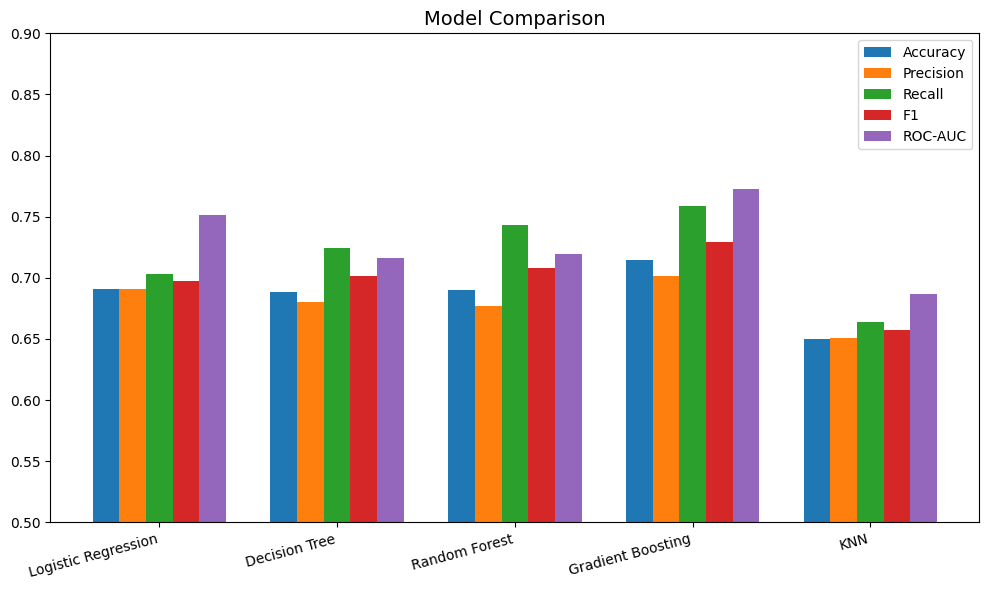

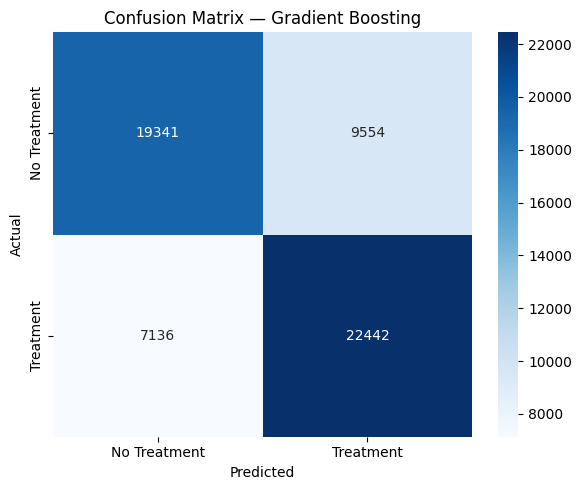

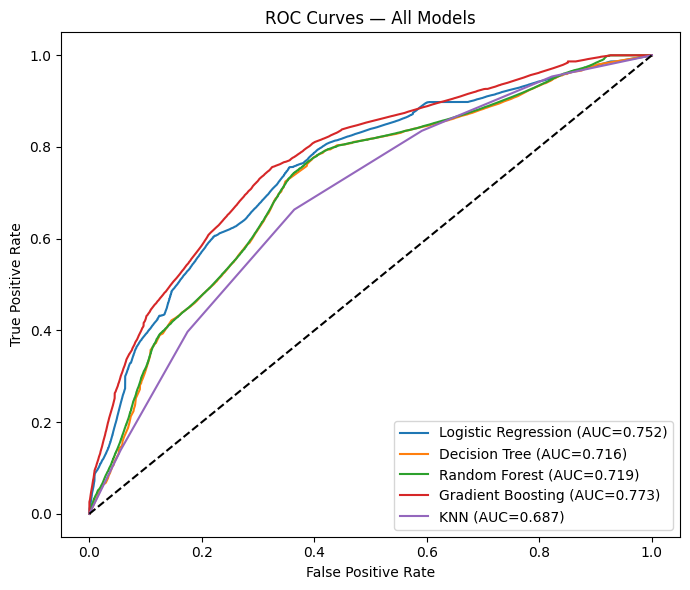

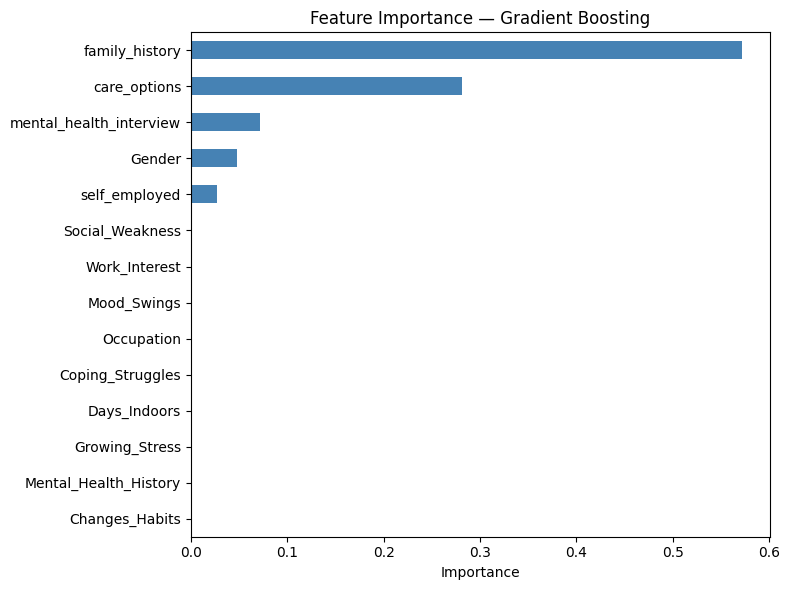

✅ All plots saved!


In [10]:
from sklearn.metrics import confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('plots', exist_ok=True)

# 1. Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(results_df.index))
width = 0.15

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results_df[metric].astype(float), width, label=metric)

ax.set_xticks(x + width*2)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylim(0.5, 0.9)
ax.set_title('Model Comparison', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150)
plt.show()

# 2. Confusion Matrix for best model (Gradient Boosting)
best_model = models['Gradient Boosting']
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Treatment', 'Treatment'],
            yticklabels=['No Treatment', 'Treatment'])
ax.set_title('Confusion Matrix — Gradient Boosting')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('plots/confusion_matrix.png', dpi=150)
plt.show()

# 3. ROC Curve
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend()
plt.tight_layout()
plt.savefig('plots/roc_curves.png', dpi=150)
plt.show()

# 4. Feature Importance
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Gradient Boosting')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150)
plt.show()

print("✅ All plots saved!")

In [11]:
import joblib

# Save the best model and label encoders
joblib.dump(best_model, 'mental_health_model.pkl')

# Save feature names
import json
with open('feature_names.json', 'w') as f:
    json.dump(X.columns.tolist(), f)

# Save unique values for each feature (needed for the app dropdowns)
from sklearn.preprocessing import LabelEncoder

# Reload original data to get original labels
df_orig = pd.read_csv('Mental Health Dataset.csv')
df_orig = df_orig.drop(['Timestamp', 'Country'], axis=1)
df_orig['self_employed'] = df_orig['self_employed'].fillna('No')

feature_options = {}
for col in df_orig.columns:
    if col != 'treatment':
        feature_options[col] = sorted(df_orig[col].unique().tolist())

with open('feature_options.json', 'w') as f:
    json.dump(feature_options, f)

print("✅ Model saved!")
print("✅ Feature options saved!")
print("\nFeatures:", X.columns.tolist())
print("\nSample options:", {k: v for k, v in list(feature_options.items())[:3]})

✅ Model saved!
✅ Feature options saved!

Features: ['Gender', 'Occupation', 'self_employed', 'family_history', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']

Sample options: {'Gender': ['Female', 'Male'], 'Occupation': ['Business', 'Corporate', 'Housewife', 'Others', 'Student'], 'self_employed': ['No', 'Yes']}


In [12]:
import shutil

# Save model and files to Drive
drive_path = '/content/drive/MyDrive/mental_health_predictor'
os.makedirs(drive_path, exist_ok=True)

shutil.copy('mental_health_model.pkl', f'{drive_path}/mental_health_model.pkl')
shutil.copy('feature_names.json', f'{drive_path}/feature_names.json')
shutil.copy('feature_options.json', f'{drive_path}/feature_options.json')
shutil.copytree('plots', f'{drive_path}/plots', dirs_exist_ok=True)

print("✅ All files saved to Drive!")

✅ All files saved to Drive!


In [13]:
from google.colab import drive
import os

# Find the file ID
!find /content/drive/MyDrive/mental_health_predictor -name "*.pkl"

# Get shareable info
model_path = '/content/drive/MyDrive/mental_health_predictor/mental_health_model.pkl'
print(f"Model size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")

/content/drive/MyDrive/mental_health_predictor/mental_health_model.pkl
Model size: 0.14 MB


In [14]:
df_orig = pd.read_csv('Mental Health Dataset.csv')
for col in df_orig.columns:
    if col not in ['Timestamp', 'Country', 'treatment']:
        print(f"{col}: {sorted(df_orig[col].dropna().unique().tolist())}")

Gender: ['Female', 'Male']
Occupation: ['Business', 'Corporate', 'Housewife', 'Others', 'Student']
self_employed: ['No', 'Yes']
family_history: ['No', 'Yes']
Days_Indoors: ['1-14 days', '15-30 days', '31-60 days', 'Go out Every day', 'More than 2 months']
Growing_Stress: ['Maybe', 'No', 'Yes']
Changes_Habits: ['Maybe', 'No', 'Yes']
Mental_Health_History: ['Maybe', 'No', 'Yes']
Mood_Swings: ['High', 'Low', 'Medium']
Coping_Struggles: ['No', 'Yes']
Work_Interest: ['Maybe', 'No', 'Yes']
Social_Weakness: ['Maybe', 'No', 'Yes']
mental_health_interview: ['Maybe', 'No', 'Yes']
care_options: ['No', 'Not sure', 'Yes']


In [15]:
print(X_train.shape)

(233891, 14)


In [16]:
!pip install xgboost shap -q

from xgboost import XGBClassifier
import shap

# Train XGBoost
print("Training XGBoost...")
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"XGBoost ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"XGBoost F1: {f1_score(y_test, y_pred_xgb):.4f}")

Training XGBoost...
XGBoost Accuracy: 0.7139
XGBoost ROC-AUC: 0.7694
XGBoost F1: 0.7314


In [17]:
# SHAP explanations for Gradient Boosting
print("Computing SHAP values (this may take a few minutes)...")
explainer = shap.TreeExplainer(best_model)

# Use a sample for speed
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=X.columns.tolist(), show=False)
plt.tight_layout()
plt.savefig('plots/shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()

# Bar plot
plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=X.columns.tolist(), plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('plots/shap_bar.png', dpi=150, bbox_inches='tight')
plt.close()

print("✅ SHAP plots saved!")

Computing SHAP values (this may take a few minutes)...
✅ SHAP plots saved!


In [18]:
import shutil

# Save new plots to Drive
drive_path = '/content/drive/MyDrive/mental_health_predictor'
shutil.copy('plots/shap_summary.png', f'{drive_path}/plots/shap_summary.png')
shutil.copy('plots/shap_bar.png', f'{drive_path}/plots/shap_bar.png')

print("✅ Saved to Drive!")

✅ Saved to Drive!
